### Linear Regression practical use case.

In [1]:
# import necessary libs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

### Loading dataset ...

In [2]:
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing(as_frame=True)
print(california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

**NOTE**: It is already given that the dataset do not contains any missing columns.
<br/>
Therefore, we begin with checking the distribution of features and correlation of features.

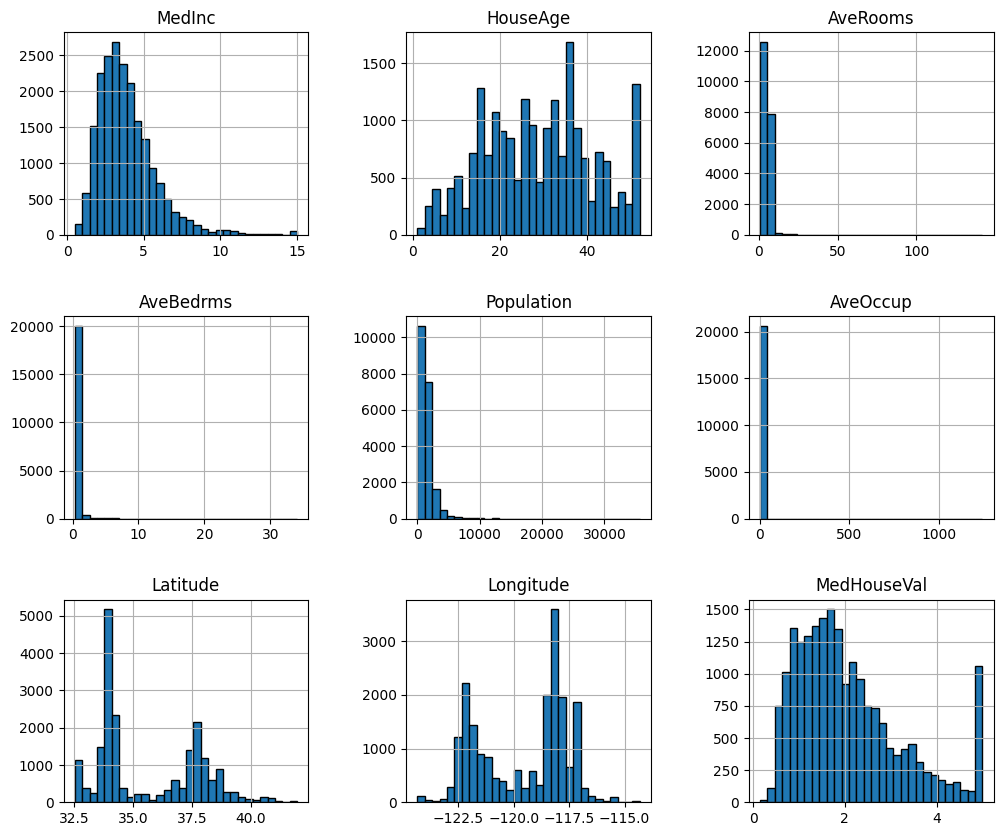

In [3]:
california_housing.frame.hist(figsize=(12,10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.4, wspace=0.4)

**Checking correlation between columns**
<br/>
As we can see clearly that columns like `AveRooms` and `AveBedrms` are highly correlated, It's better if we any one of them.
<br/>
Another correlated columns are `Latitude` and `Longitude` column, which are both negatively correlated. But we can't drop them directly because it tells the location of the households. Later columns like these are useful.

<Axes: >

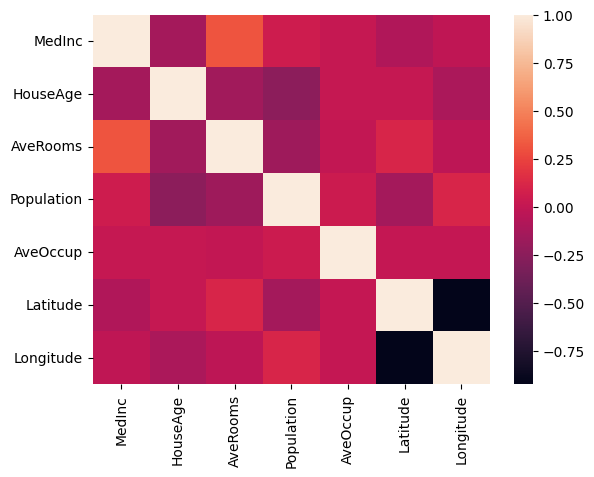

In [17]:
df = california_housing.data

# print(df.corr())
sns.heatmap(df.corr())

In [6]:
df.drop(columns=['AveBedrms'], inplace=True)

C:\Users\papsr\AppData\Local\Temp\ipykernel_9020\1440013603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['AveBedrms'], inplace=True)


First perform the `log` transformation on the `MedInc`, `Population` column. As we can clearly see that these columns are heavily left skewed.

In [7]:
df["MedInc"] = np.log( df.MedInc )
df["Population"] = np.log( df.Population)

C:\Users\papsr\AppData\Local\Temp\ipykernel_9020\702987010.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["MedInc"] = np.log( df.MedInc )
C:\Users\papsr\AppData\Local\Temp\ipykernel_9020\702987010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Population"] = np.log( df.Population)


In [8]:
df.sample(5)

,MedInc,HouseAge,AveRooms,Population,AveOccup,Latitude,Longitude
15021,0.993474,17.0,4.499388,8.111028,2.038556,32.79,-117.03
9414,1.912043,35.0,5.168561,6.876265,1.835227,37.86,-122.49
9076,1.361694,35.0,5.713761,7.587817,3.622018,34.69,-118.16
2141,0.892203,35.0,4.665289,6.161207,1.958678,36.78,-119.75
3438,1.360977,37.0,4.352798,7.731492,5.545012,34.26,-118.42


**Before going further**, first we'll extract the training and testing features from the dataset.
<br/>
Below given code segment does the same.

In [9]:
X = df.values
y = california_housing.target

X.shape, y.shape

((20640, 7), (20640,))

From the above graph we can clearly notice, that our target columns is also left skewed. so we perform the same `log` transformation which we done before.

In [10]:
y = np.log1p(y)

### Splitting dataset into training and testing

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                   random_state=42,
                                                   test_size=0.3)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((14448, 7), (6192, 7), (14448,), (6192,))

**Now we perform, scaling operation on the above features.**
<br/>
As we know, these two features tells the location of the households, no need to delete them so quickly.

In [12]:
std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)

**After all this preprocessing, now it's time for model training.**

In [13]:
# model training begins ...

lin_regression = LinearRegression(n_jobs=-1)
lin_regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


While testing using `X_test`, first we've to perform the exact same scaling step, which we've done with `X_train`.

In [14]:
X_test = std_scaler.transform(X_test)

Now, we'll perform the prediction on the test set using our regression model.

In [18]:
y_pred_log = lin_regression.predict(X_test)

# convert this back to original scale
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

### Evaluating performance using RMSE

In [19]:
print(
    "RMSE : ", (mean_squared_error( y_test_actual, y_pred ) ** 0.5)
)

RMSE :  0.7325510388659637
